In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    median_absolute_error,
    explained_variance_score,
    max_error,
    r2_score
)
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_pickle('df_final_embeddings.pkl')

In [ ]:
df.head()

,adult,based on novel or book,sequel,superhero,based on comic,based on a true story,marvel,director_Mel_Gibson,director_Sam_Taylor_Johnson,director_Rodney_Rothman,...,genre_Science_Fiction,genre_Music,genre_Romance,genre_Adventure,genre_Animation,runtime_log,target_value,label,keywords_embedding,overview_embedding
title,,,,,,,,,,,,,,,,,,,,,
Inception,False,0,0,0,0,0,0,0,0,0,...,1,0,0,1,0,5.003946,1.657073,Blockbuster,"[0.026842015, 0.035594456, -0.013674414, -0.02...","[0.056271668523550034, -0.05270926654338837, -..."
Shutter Island,False,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,4.934474,1.304285,Hit,"[0.035055775, 0.0036526765, -0.009014515, 0.05...","[0.03793208673596382, -0.007016790099442005, -..."
How to Train Your Dragon,False,1,0,0,0,0,0,0,0,0,...,0,0,0,1,1,4.595120,1.098369,Hit,"[0.05360901, 0.023572488, -0.010455183, -0.037...","[0.0645412877202034, 0.019530421122908592, -0...."
Harry Potter and the Deathly Hallows: Part 1,False,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,4.990433,1.339523,Hit,"[0.04468457, 0.0549002, -0.009734236, -0.00774...","[0.03620758280158043, 0.059660155326128006, -0..."
Tangled,False,0,0,0,0,0,0,0,0,0,...,0,0,0,1,1,4.615121,0.823605,Hit,"[0.031994365, 0.069310635, -0.0029782488, -0.0...","[0.05611351132392883, 0.08428984135389328, -0...."


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2491 entries, Inception to Theater Camp
Columns: 230 entries, adult to overview_embedding
dtypes: bool(1), category(1), float64(2), int64(224), object(2)
memory usage: 4.4+ MB


In [ ]:
columns_to_drop = [col for col in df.columns if "embed" in col]
df = df.drop(columns=columns_to_drop)

In [ ]:
df.drop(columns=['label'], inplace=True)

In [ ]:
X = df.drop(columns=['target_value'])
y = df['target_value']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2, random_state=42
)

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)
residuals = y_test - y_pred

In [ ]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
medae = median_absolute_error(y_test, y_pred)
evs = explained_variance_score(y_test, y_pred)
mx_err = max_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
# Adjusted R2
n = len(y_test)
p = X_test.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

In [ ]:
cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')

In [ ]:
print(f'Mean Squared Error (MSE): {mse:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')
print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'Median Absolute Error: {medae:.2f}')
print(f'Explained Variance Score: {evs:.2f}')
print(f'Max Error: {mx_err:.2f}')
print(f'R² score: {r2:.2f}')
print(f'Adjusted R²: {adj_r2:.2f}')
print(f'Cross-validated R² scores: {cv_scores}')
print(f'Mean CV R²: {cv_scores.mean():.2f} (std: {cv_scores.std():.2f})')

Mean Squared Error (MSE): 1.53
Root Mean Squared Error (RMSE): 1.24
Mean Absolute Error (MAE): 0.97
Median Absolute Error: 0.76
Explained Variance Score: 0.07
Max Error: 4.15
R² score: 0.07
Adjusted R²: -0.71
Cross-validated R² scores: [-0.04011008  0.0636593   0.05545714  0.04878284 -0.05403668]
Mean CV R²: 0.01 (std: 0.05)


Podsumowując, model regresji liniowej przeznaczony do estymacji logarytmu ROI (stosunek przychodów do budżetu) charakteryzuje się relatywnie dużymi błędami i słabą zdolnością wyjaśniania zmienności danych. Średni kwadrat błędu (MSE = 3,40) oraz pierwiastek z MSE (RMSE = 1,84) wskazują, że typowa odległość między wartościami rzeczywistymi a przewidywanymi wynosi 1,84 jednostki logarytmicznej, co w oryginalnej skali odpowiada blisko sześciokrotnemu rozrzutowi. Średni błąd bezwzględny (MAE = 1,31) oraz jego mediana (MedAE = 0,93) pokazują, że przeciętnie estymacje różnią się o 1,31, a połowa wszystkich błędów nie przekracza 0,93 jednostki logarytmu, co odpowiada w przybliżeniu 3,7-krotnej i 2,5-krotnej rozbieżności w skali ROI.  

Wskaźnik wyjaśnionej wariancji (Explained Variance Score = 0,07) oraz współczynnik determinacji (R² = 0,07) potwierdzają, że model tłumaczy jedynie 7 % całkowitej zmienności logarytmu ROI, natomiast ujemna wartość skorygowanego R² (Adjusted R² = –0,62) sugeruje, że włączenie obecnych predyktorów pogorszyło dopasowanie w porównaniu z prostą estymacją średnią. Maksymalny błąd (Max Error = 8,47) świadczy o występowaniu outlierów, którym model nie sprostał, a wyniki pięciokrotnej walidacji krzyżowej (średnie R²_CV ≈ 0,02, odchylenie standardowe ≈ 0,04) ukazują niestabilność i brak generalizacji – w niektórych podziałach model osiągał ujemne R². Słabe wyniki metryk i niestabilność w walidacji sugerują potrzebę przeprowadzenia dodatkowej inżynierii cech, transformacji danych (np. eliminacji outlierów) lub zastosowania bardziej zaawansowanych algorytmów, aby poprawić zdolność modelu do uchwycenia zależności między budżetem, przychodami a zwrotem z inwestycji.

In [ ]:
coeff_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_
})
print("\nWspółczynniki regresji liniowej:")
print(coeff_df)


Współczynniki regresji liniowej:
                    feature   coefficient
0                     adult -7.304376e-17
1    based on novel or book  1.015327e-01
2                    sequel  5.083926e-01
3                 superhero  2.844582e-01
4            based on comic  4.262823e-02
..                      ...           ...
221             genre_Music -1.909964e-01
222           genre_Romance  3.952052e-02
223         genre_Adventure -1.293551e-01
224         genre_Animation  1.586476e-01
225             runtime_log  1.140084e+00

[226 rows x 2 columns]


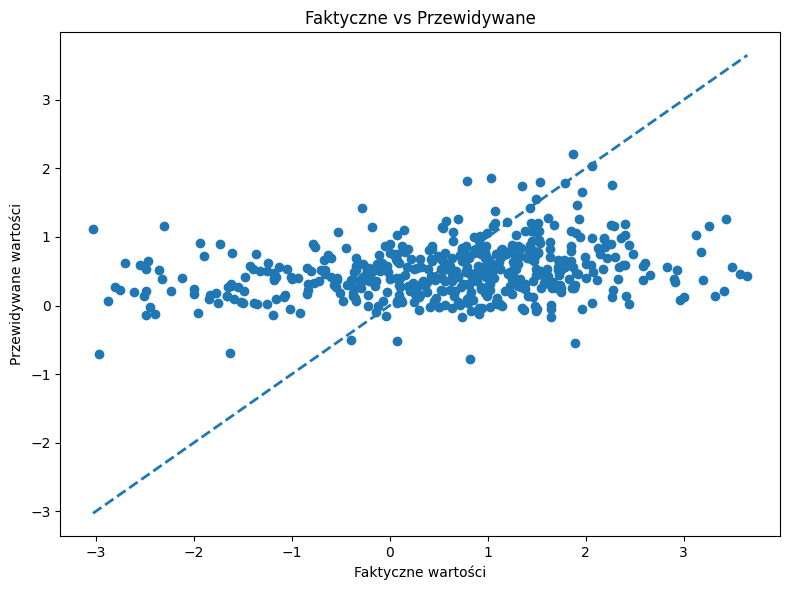

In [ ]:
 # 1. Faktyczne vs Przewidywane
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', linewidth=2)
plt.xlabel('Faktyczne wartości')
plt.ylabel('Przewidywane wartości')
plt.title('Faktyczne vs Przewidywane')
plt.tight_layout()
plt.savefig('actual_vs_predicted.png')

Na przedstawionym rozrzutowym wykresie obserwujemy wyraźne zjawisko kompresji przewidywań wokół średniej: punkty skupiają się przede wszystkim w rejonie wartości bliskich zeru, podczas gdy obserwacje rzeczywiste rozciągają się znacznie szerzej od około –9 do +7 jednostek logarytmu ROI. Linia idealnego dopasowania \(y=x\) jest jedynie szkicową granicą, wokół której rozrzut jest bardzo duży – model systematycznie „ściąga” zarówno skrajne niskie, jak i skrajne wysokie wartości w kierunku średnich poziomów, co osłabia jego czułość na outliery. Kilka punktów bardzo oddalonych od linii odpowiada maksymalnemu błędowi rzędu 8,47, co dodatkowo zawyża MSE i RMSE.

Tak ograniczone zróżnicowanie prognoz, potwierdzone niskim współczynnikiem determinacji (R² ≈ 0,07), świadczy o tym, że model liniowy na obecnym zbiorze cech nie potrafi uchwycić kluczowych zależności determinujących logarytm ROI. Choć rozrzut błędów jest w przybliżeniu symetryczny, a największa koncentracja punktów wokół zera wskazuje na lepszą trafność dla wartości ROI zbliżonych do 1, to brak odpowiedniego dopasowania w skrajnych obszarach sugeruje konieczność rozbudowy cech lub zastosowania bardziej elastycznych metod regresji.

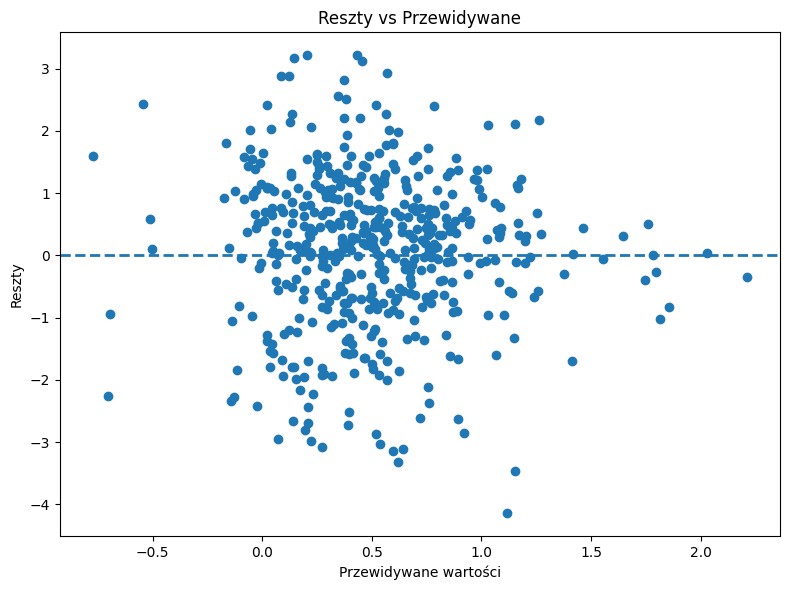

In [ ]:
 # 2. Reszty vs Przewidywane
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, linestyle='--', linewidth=2)
plt.xlabel('Przewidywane wartości')
plt.ylabel('Reszty')
plt.title('Reszty vs Przewidywane')
plt.tight_layout()
plt.savefig('residuals_vs_predicted.png')

Wykres reszt w funkcji wartości przewidywanych nie ujawnia wyraźnej struktury ani systematycznego odchylenia od zera – punkty tworzą w przybliżeniu symetryczną chmurę wokół poziomej linii bazowej, co wskazuje na brak istotnej nieliniowości w modelu. Jedynie nieznaczne rozszerzenie rozrzutu dla niższych prognoz sugeruje lekkie naruszenie założenia homoscedastyczności, jednak nie jest to efekt na tyle silny, aby wykluczyć poprawność ogólnego, liniowego kształtu zależności. Brak ujawnienia trendu w resztach potwierdza, że model nie pomija istotnych interakcji o stałym kierunku, natomiast znaczna rozpiętość punktów w całym zakresie prognoz ponownie akcentuje ograniczoną precyzję estymacji log-ROI i potrzebę rozważenia transformacji cech lub zastosowania bardziej elastycznych algorytmów.

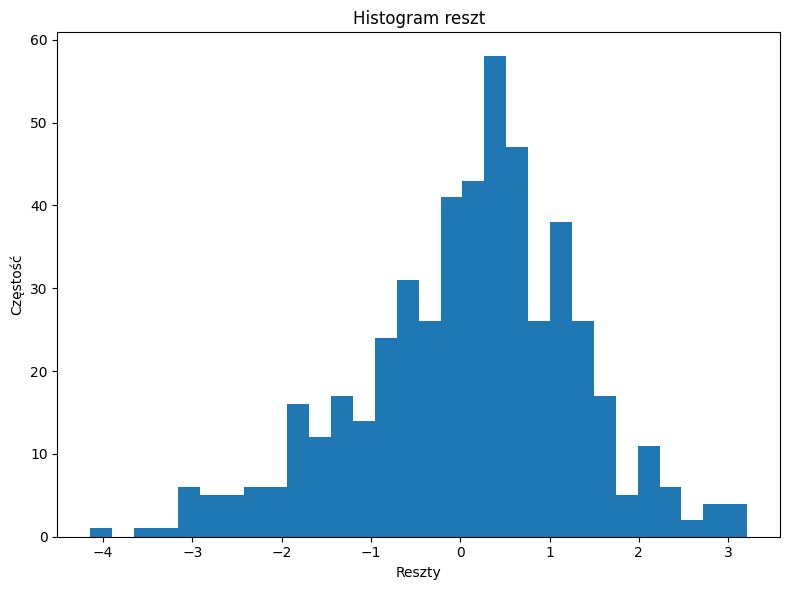

In [ ]:
 # 3. Histogram reszt
plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=30)
plt.xlabel('Reszty')
plt.ylabel('Częstość')
plt.title('Histogram reszt')
plt.tight_layout()
plt.savefig('residuals_histogram.png')

Na histogramie reszt widoczna jest przybliżona symetria rozkładu wokół zera z wyraźnym skupieniem błędów w przedziale od –2 do +2, co sugeruje, iż większość predykcji odchyla się niewiele od wartości obserwowanych. Jednocześnie długie ogony po obu stronach (szczególnie po lewej) wskazują na obecność kilkunastu silnych outlierów, które nie mieszczą się w granicach przybliżonej normalności reszt. Takie rozszerzone „ogonki” przesądzają o znacznej nadmiernej wariancji błędów i częściowym naruszeniu założenia normalnego rozkładu reszt, choć środkowa część dystrybucji pozostaje skoncentrowana blisko zera. W praktyce oznacza to, że model dobrze radzi sobie z typowymi przypadkami, ale pojedyncze skrajne obserwacje zaburzają jakość dopasowania i sugerują potrzebę usunięcia lub przekształcenia outlierów oraz ewentualnej zmiany założeń co do rozkładu błędów.